# Overview

In this notebook we analyze the full historical series of the S&P 500 and tackle two distinct machine-learning problems:

1. **Forecasting next-day log-returns** using a neural network trained on past prices.  
2. **Applying the Triple Barrier Method**, introduced by López de Prado, to frame a classification task where the model must predict whether, within a future horizon, the price first hits the upper barrier, the lower barrier, or neither.

To evaluate temporal generalization, we adopt a *rolling evaluation scheme*:  
the model is trained once on the first 70% of the data and then tested on **10 consecutive, non-overlapping test windows** that move forward in time.  

This methodology allows us to assess whether the neural network genuinely learns meaningful patterns in the data, or merely exploits the long-term upward trend of the index.

The triple-barrier classification task is particularly useful in this regard, as it forces the model to distinguish local price dynamics rather than simply reproducing the global drift.


In [1]:
# Download data for the S&P 500 index from Yahoo Finance and save it to a CSV file.
#import yfinance as yf
#sp500_data = yf.download('^GSPC', start='1900-01-01')
#sp500_data.to_csv("sp500_data_long.csv")

In [2]:
# Import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from fracdiff.sklearn import Fracdiff
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score
from statsmodels.tsa.stattools import adfuller
from torch.utils.data import TensorDataset, DataLoader
from mypackage_utils import *

# For reproducibility
np.random.seed(42)
random.seed(42) 
from pathlib import Path
datasets = Path("dataset")

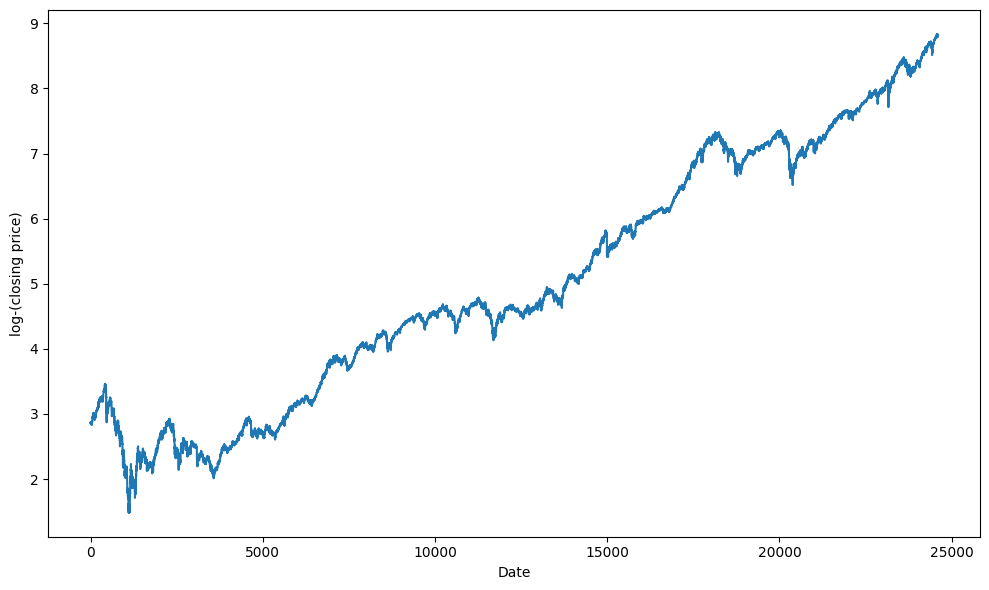

ADF test statistic: 0.840196239414464, p-value: 0.9922580695843458


In [3]:
sp500 = np.log(np.maximum(reading_file(datasets / "sp500_data_long.csv").astype(float), 1e-8)) 
# We focus on the 'Close' prices
sp500 = sp500['Close'].to_numpy()
# Plot data
plt.figure(figsize=(10, 6))
plt.plot(sp500)
plt.xlabel("Date")
plt.ylabel("log-(closing price)")
plt.tight_layout()
plt.show()
# To check for stationarity, we perform the Augmented Dickey-Fuller test ( as by De Prado methodology )
adf_results = adfuller(sp500)
print(f"ADF test statistic: {adf_results[0]}, p-value: {adf_results[1]}")


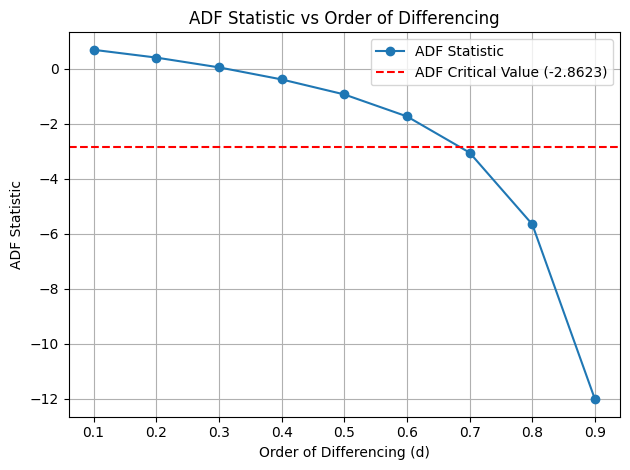

Estimated order of stationarity : ~ 0.685


In [4]:
# Find the best order of differentiation to make the series stationary. 

# Plot the ADF results vs order of differentiation
d_grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

cval = -2.8623  # ADF critical value at 5% for n > 1000
window_size = 100
rows = []
for d in d_grid:
	frac = Fracdiff(d, window=window_size, window_policy="fixed") 	# the window size is now default=10   
	X = sp500.reshape(-1, 1)     
	X_fd = frac.fit_transform(X).ravel()
	# Set first (window_size - 1) values to NaN due to fixed window policy
	X_fd[:(window_size - 1)] = np.nan  
	# Remove NaN values for ADF test     								
	adf_results = adfuller(X_fd[~np.isnan(X_fd)])  
	rows.append({
		"d": d, "series": X_fd,
		"adf_stat": adf_results[0], "adf_p": adf_results[1],
	})
d_values = [r['d'] for r in rows]
adf_stats = [r['adf_stat'] for r in rows]
plt.title(f"ADF Statistic vs Order of Differencing")
plt.plot(d_values, adf_stats, marker='o', label='ADF Statistic')
plt.axhline(y=cval, color='r', linestyle='--', label='ADF Critical Value (-2.8623)')
plt.xlabel("Order of Differencing (d)")
plt.ylabel("ADF Statistic")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
# Intersection between ADF stats and critical value: find first crossing where ADF goes from > cval to <= cval
d_values  = np.asarray(d_values, dtype=float)
adf_stats = np.asarray(adf_stats, dtype=float)
mask = (adf_stats[:-1] > cval) & (adf_stats[1:] <= cval)
idx = np.where(mask)[0]
i = idx[0]
# Linear interpolation
d1, d2 = d_values[i], d_values[i+1]
a1, a2 = adf_stats[i], adf_stats[i+1]
d_star = d1 + (cval - a1) * (d2 - d1) / (a2 - a1)
print(f"Estimated order of stationarity : ~ {d_star:.3f}")

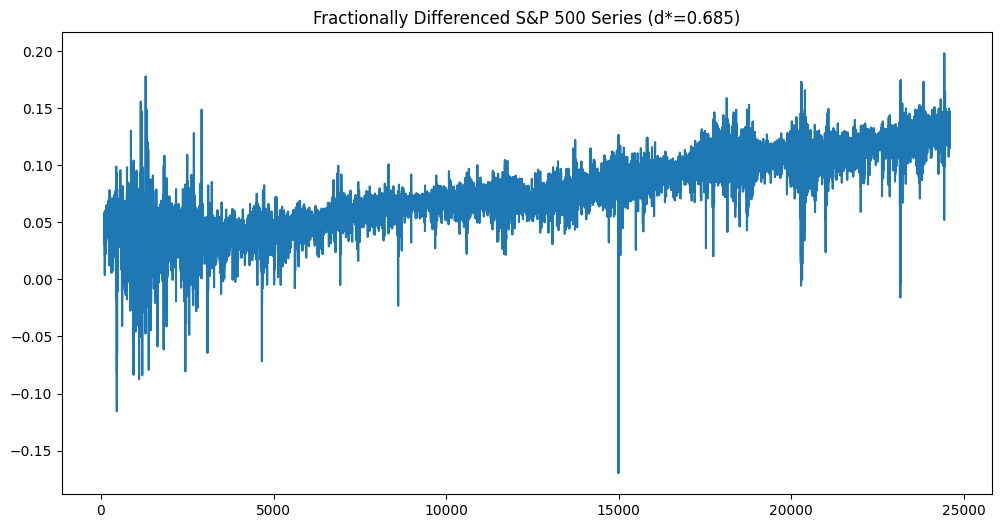

In [5]:
# Determine the fractionally differenced series using the estimated d_star
fd_sp500 = Fracdiff(d=d_star, window=window_size, window_policy="fixed")
dataset = fd_sp500.fit_transform(sp500.reshape(-1, 1)).ravel()
dataset[:(window_size - 1)] = np.nan
plt.figure(figsize=(12, 6))
plt.title(f"Fractionally Differenced S&P 500 Series (d*={d_star:.3f})")
plt.plot(dataset)
plt.show()

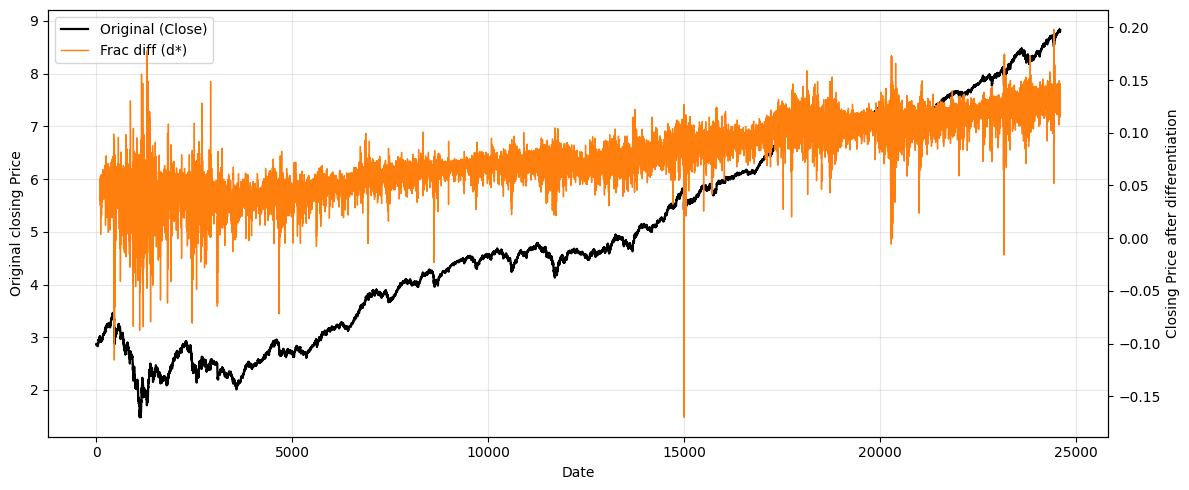

In [6]:
#Plot the original, integer-differenced, and fractionally differenced series on the same figure using twin y-axes.

fig, ax1 = plt.subplots(figsize=(12, 5))

# Left axis: original prices 
ax1.plot( sp500, lw=1.6, color="black", label="Original (Close)")
ax1.set_ylabel("Original closing Price")
ax1.set_xlabel("Date")

# Right axis: integer and fractional differences 
ax2 = ax1.twinx()
ax2.plot( dataset, lw=1.0, color="tab:orange", label="Frac diff (d*)")
ax2.set_ylabel("Closing Price after differentiation")

# Legend 
lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Regression problem 

## NN

In [7]:
# Prepare dataset for ML algorithms
# Log returns as target variable
target = np.diff(sp500)
mask = np.isfinite(dataset[:-1]) & np.isfinite(target)
X = dataset[:-1][mask].reshape(-1, 1)
y = target[mask].reshape(-1, 1)

# Split the data into training and testing sets
train_size = int(len(X) * 0.70)
test_size = int(len(X) * 0.03)
train_data = X[:train_size]
target_train = y[:train_size]

# Normalize data
scaler_data = StandardScaler()
train_data = scaler_data.fit_transform(train_data)
test_data = []
target_test = []
for i in range(10):
	test_data.append(scaler_data.transform(X[train_size + i * test_size:train_size + (i + 1) * test_size]))
	target_test.append(y[train_size + i * test_size:train_size + (i + 1) * test_size])

100%|██████████| 300/300 [00:10<00:00, 28.74it/s, lr=0.001, train=0.00014] 


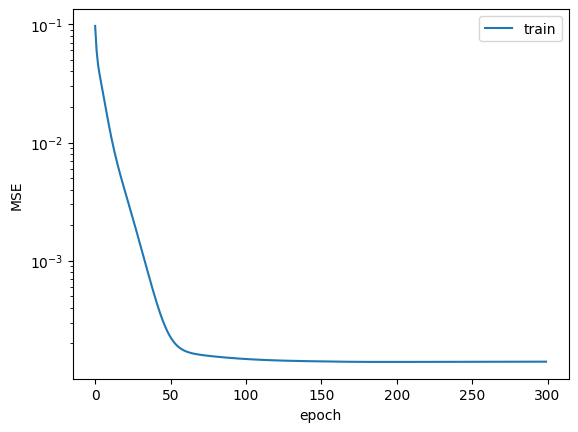

In [8]:
# Define the MLP model
batch_size = 512
nhidden = 4
model = nn.Sequential(nn.Linear(1, nhidden),
						nn.ReLU(),
						nn.Linear(nhidden, 1))

# Transforming data into tensor
train_data = torch.as_tensor(train_data, dtype=torch.float32)
target_train = torch.as_tensor(target_train, dtype=torch.float32).view(-1, 1)
for i in range (10):
	test_data[i] = torch.as_tensor(test_data[i], dtype=torch.float32)
	target_test[i] = torch.as_tensor(target_test[i], dtype=torch.float32).view(-1, 1)

# Dataset e DataLoader
train_dataset = TensorDataset(train_data, target_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False) # Shuffle False because of time series data

# Defining loss, optimizer 
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Training loop
n_epochs = 300
train_curve= []
training_loop = tqdm(range(n_epochs)) 

for epoch in training_loop:
	# Training mode
	model.train() 
	running = 0.0 
	for batch_data, batch_targets in train_loader:
		# Reset computation graph
		optimizer.zero_grad()
		# Forward pass
		outputs = model(batch_data)
		# Compute training loss on batch
		loss = criterion(outputs, batch_targets)
		# Compute gradient 
		loss.backward()
		# Gradient step
		optimizer.step()
		# Loss per batch 
		running += loss.item()
	# Loss per epoch
	train_epoch = running/len(train_loader)

	# Store train and validation loss
	train_curve.append(train_epoch)

	# Print loss in the progression bar
	training_loop.set_postfix(train=train_epoch,  lr=optimizer.param_groups[0]['lr'])

# Plot losses
plt.figure()
plt.plot(train_curve, label='train')
plt.yscale('log') 
plt.legend(); plt.xlabel('epoch'); plt.ylabel('MSE')
plt.show()			


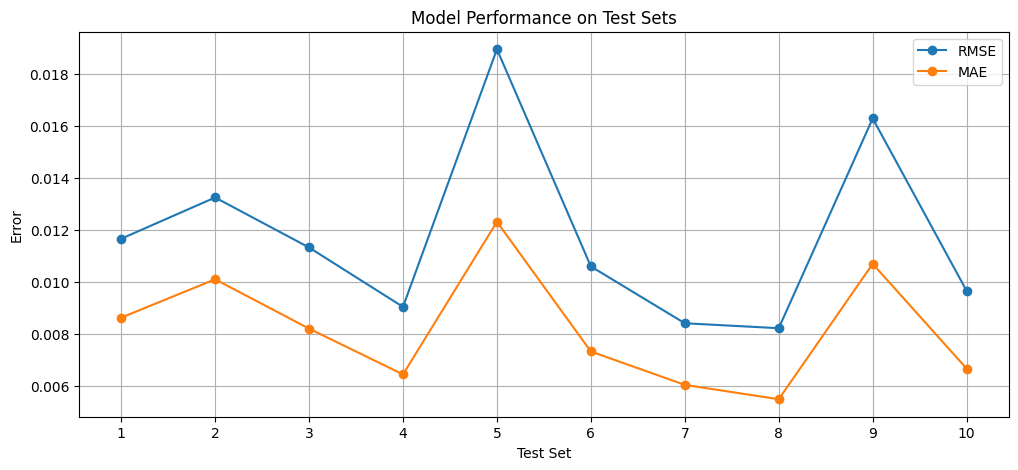

Train RMSE: 0.012054, MAE: 0.007741
Test Set 1: sample standard deviation of the predictions = 0.000510
Test Set 2: sample standard deviation of the predictions = 0.000606
Test Set 3: sample standard deviation of the predictions = 0.000506
Test Set 4: sample standard deviation of the predictions = 0.000403
Test Set 5: sample standard deviation of the predictions = 0.000690
Test Set 6: sample standard deviation of the predictions = 0.000464
Test Set 7: sample standard deviation of the predictions = 0.000389
Test Set 8: sample standard deviation of the predictions = 0.000385
Test Set 9: sample standard deviation of the predictions = 0.000643
Test Set 10: sample standard deviation of the predictions = 0.000449


In [9]:
# Metrics evaluation 
rmse_list_nn = []
mae_list_nn = []
std_nn = []
train_evaluation = []
prediction_nn = []
model.eval()
with torch.no_grad():
	# Train evaluation
	predcitions_train = model(train_data).numpy()
	train_evaluation.append( np.sqrt(mean_squared_error(target_train.numpy(), predcitions_train)))
	train_evaluation.append(mean_absolute_error(target_train.numpy(), predcitions_train))
	# Test evaluation on 10 test sets
	for i in range(10):
		predictions = model(test_data[i]).numpy()
		prediction_nn.append(predictions)
		std_nn.append(np.std(predictions))
		rmse_list_nn.append( np.sqrt( mean_squared_error(target_test[i].numpy(), predictions) ))
		mae_list_nn.append(mean_absolute_error(target_test[i].numpy(), predictions))

# Plot the metric evaluation on the 10 test sets
plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), rmse_list_nn, marker='o', label='RMSE')
plt.plot(range(1, 11), mae_list_nn, marker='o', label='MAE')
plt.title("Model Performance on Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Error")
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show()
print(f"Train RMSE: {train_evaluation[0]:.6f}, MAE: {train_evaluation[1]:.6f}")
# Print sample standard deviation of predictions on each test set
for i in range(10):
	print(f"Test Set {i+1}: sample standard deviation of the predictions = {std_nn[i]:.6f}")


## LR

In [10]:
model_lr = LinearRegression()
model_lr.fit(train_data, target_train)
# Save the linear regression model
#joblib.dump(model, weight_filename)
rmse_list_lr = []
mae_list_lr = []
std_lr = []
prediction_lr = []
# Evaluate model on training set
pred_train_lr = model_lr.predict(train_data)
train_evaluation_lr = []
train_evaluation_lr.append( np.sqrt(mean_squared_error(target_train.numpy(), pred_train_lr)))
train_evaluation_lr.append(mean_absolute_error(target_train.numpy(), pred_train_lr))
# Evaluate model on test sets 
for i in range(10):
	pred = model_lr.predict(test_data[i])
	prediction_lr.append(pred)
	std_lr.append(np.std(pred))
	rmse_list_lr.append(np.sqrt(mean_squared_error(target_test[i].numpy(), pred)))
	mae_list_lr.append(mean_absolute_error(target_test[i].numpy(), pred))

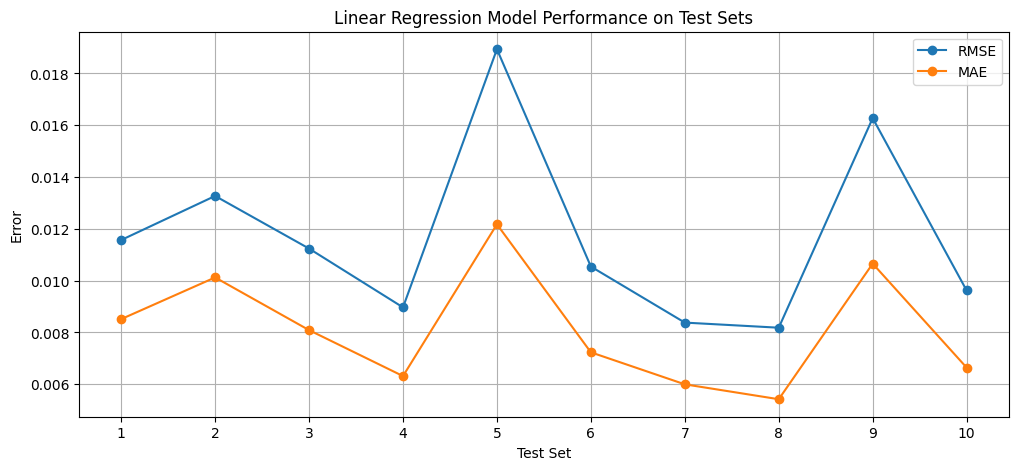

Train RMSE: 0.011886, MAE: 0.007411
Test Set 1: sample standard deviation of the predictions = 0.000102
Test Set 2: sample standard deviation of the predictions = 0.000117
Test Set 3: sample standard deviation of the predictions = 0.000100
Test Set 4: sample standard deviation of the predictions = 0.000075
Test Set 5: sample standard deviation of the predictions = 0.000163
Test Set 6: sample standard deviation of the predictions = 0.000093
Test Set 7: sample standard deviation of the predictions = 0.000073
Test Set 8: sample standard deviation of the predictions = 0.000072
Test Set 9: sample standard deviation of the predictions = 0.000139
Test Set 10: sample standard deviation of the predictions = 0.000086


In [11]:
# Plot the metric evaluation on the 10 test sets
plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), rmse_list_lr, marker='o', label='RMSE')
plt.plot(range(1, 11), mae_list_lr, marker='o', label='MAE')
plt.title("Linear Regression Model Performance on Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Error")
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show()
print(f"Train RMSE: {train_evaluation_lr[0]:.6f}, MAE: {train_evaluation_lr[1]:.6f}")
# Print sample standard deviation of predictions on each test set
for i in range(10):
	print(f"Test Set {i+1}: sample standard deviation of the predictions = {std_lr[i]:.6f}")


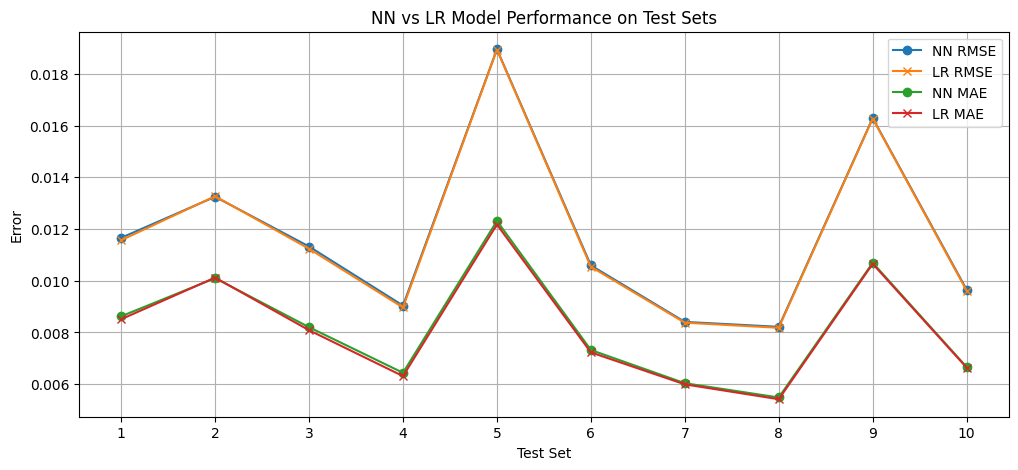

In [12]:
# Compare NN and LR models plotting the RMSE and MAE for each test set
plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), rmse_list_nn, marker='o', label='NN RMSE')
plt.plot(range(1, 11), rmse_list_lr, marker='x', label='LR RMSE')
plt.plot(range(1, 11), mae_list_nn, marker='o', label='NN MAE')
plt.plot(range(1, 11), mae_list_lr, marker='x', label='LR MAE')
plt.title("NN vs LR Model Performance on Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Error")
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show()

## Train–Test Distribution Shift

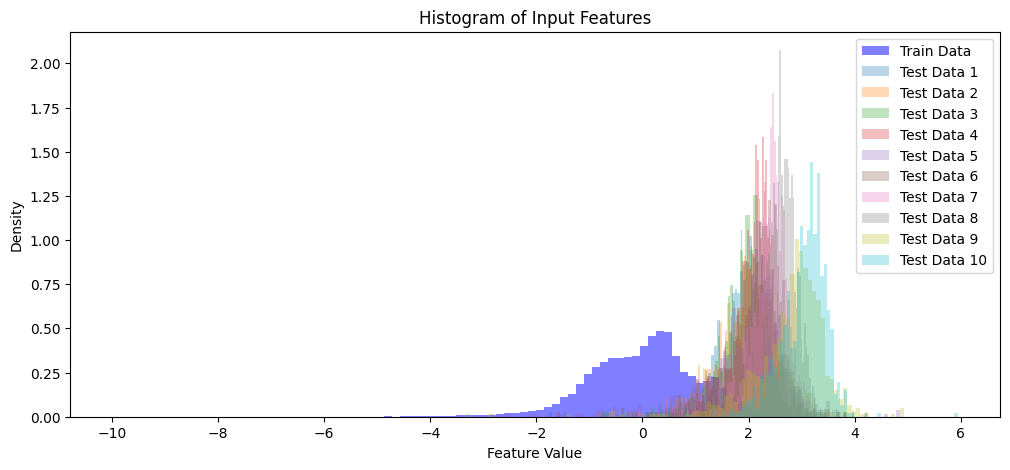

In [13]:
# Plotting histograms of input features for test sets
plt.figure(figsize=(12, 5))
plt.hist(train_data.numpy(), bins=100, alpha=0.5, label='Train Data', color='blue', density=True)
for i in range(10):
	plt.hist(test_data[i].numpy(), bins=100, alpha=0.3, label=f'Test Data {i+1}', density=True)
plt.title("Histogram of Input Features")
plt.xlabel("Feature Value")
plt.ylabel("Density")
plt.legend()
plt.show()

## NN vs LR: Learned Functions

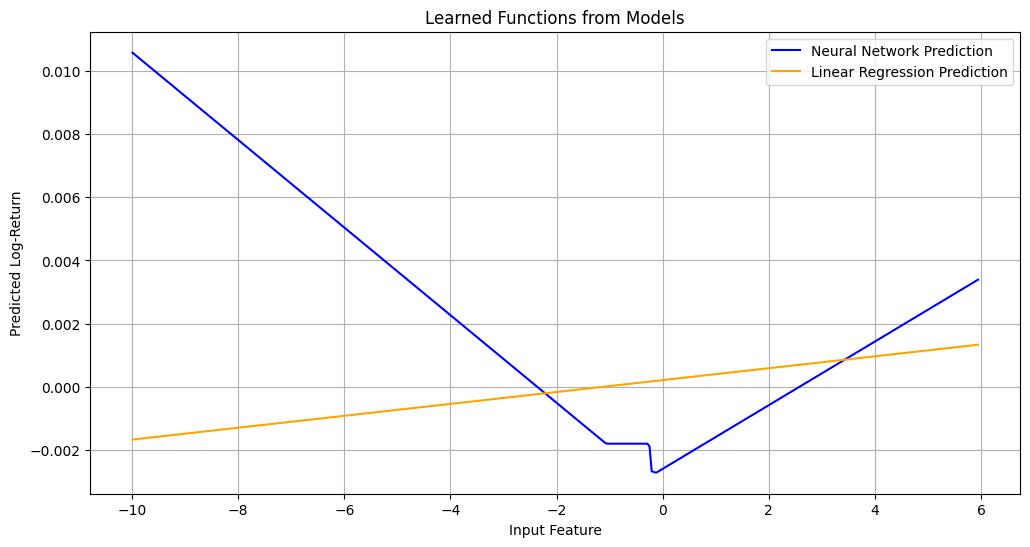

In [14]:
# Plotting the learned functions from both models
x_min = min(train_data.min(), 
            min([test_data[i].min() for i in range(10)]))
x_max = max(train_data.max(), 
            max([test_data[i].max() for i in range(10)]))
x_vals = np.linspace(x_min, x_max, 400).reshape(-1, 1)


model.eval()
with torch.no_grad():
	y_vals_nn = model(torch.as_tensor(x_vals, dtype=torch.float32)).numpy()
y_vals_lr = model_lr.predict(x_vals)
plt.figure(figsize=(12, 6))
plt.plot(x_vals, y_vals_nn, label='Neural Network Prediction', color='blue')
plt.plot(x_vals, y_vals_lr, label='Linear Regression Prediction', color='orange')
plt.title("Learned Functions from Models")
plt.xlabel("Input Feature")
plt.ylabel("Predicted Log-Return")
plt.legend()
plt.grid()
plt.show()

### Comment on results

In [15]:
# For each test set, determine the min and max and then determine the average difference in the learned functions of the two models over that range
avg_differences = []
for i in range(10):
	min_val = np.min(test_data[i].numpy())
	max_val = np.max(test_data[i].numpy())
	x_range = np.linspace(min_val, max_val, test_size).reshape(-1, 1)
	nn_preds = model(torch.as_tensor(x_range, dtype=torch.float32)).detach().numpy()
	lr_preds = model_lr.predict(x_range)
	avg_diff = np.mean(np.abs(nn_preds - lr_preds))
	avg_differences.append(avg_diff)
	print(f"Test Set {i+1}: Average difference between NN and LR predictions = {avg_diff:.6f}")
	# Plot the difference in RMSE and MAE for the corresponding test set
	print(f"Test Set {i+1}: RMSE difference = {abs(rmse_list_nn[i] - rmse_list_lr[i]):.6f}, MAE difference = {abs(mae_list_nn[i] - mae_list_lr[i]):.6f}")

Test Set 1: Average difference between NN and LR predictions = 0.001460
Test Set 1: RMSE difference = 0.000094, MAE difference = 0.000113
Test Set 2: Average difference between NN and LR predictions = 0.001363
Test Set 2: RMSE difference = 0.000021, MAE difference = 0.000022
Test Set 3: Average difference between NN and LR predictions = 0.001399
Test Set 3: RMSE difference = 0.000087, MAE difference = 0.000116
Test Set 4: Average difference between NN and LR predictions = 0.001195
Test Set 4: RMSE difference = 0.000073, MAE difference = 0.000128
Test Set 5: Average difference between NN and LR predictions = 0.001202
Test Set 5: RMSE difference = 0.000017, MAE difference = 0.000139
Test Set 6: Average difference between NN and LR predictions = 0.001450
Test Set 6: RMSE difference = 0.000053, MAE difference = 0.000092
Test Set 7: Average difference between NN and LR predictions = 0.001441
Test Set 7: RMSE difference = 0.000031, MAE difference = 0.000043
Test Set 8: Average difference bet

## Cumulative returns
To further evaluate the model, we implement a simple trading strategy based on log-return predictions. This allows us to assess the strategy's cumulative returns, specifically looking for any performance decay in the test sets.

In [16]:
def trading_sp500(predictions):
    # If instead of predicting the log-close, I predict the log-return
    # Initialize daily profit/loss (PnL)
    daily_pnl = []
    actual_price = sp500[-len(predictions)-1:]
    # If predictions[i] > 0 => P_t+1 > P_t  => long position
    # Simulate trading logic
    for i in range(len(predictions)):
        # Today's price and tomorrow's actual price
        today_price = actual_price[i]
        tomorrow_price = actual_price[i + 1]
        
        # Trading decision: long (1) or short (-1)
        position = 1 if predictions[i] > 0 else -1
        
        # Calculate profit/loss for the day
        pnl = position * (tomorrow_price - today_price)
        daily_pnl.append(pnl)
    # Calculate cumulative profit/loss
    cumulative_pnl = np.cumsum(daily_pnl)
    return cumulative_pnl

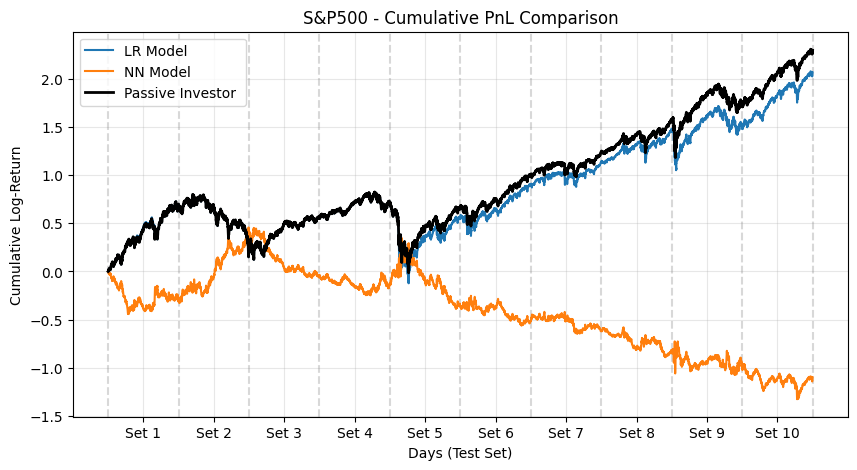

In [17]:
# Numero di predizioni effettuate
N = len(np.vstack(prediction_lr).ravel())

set_size = len(prediction_lr[0])
n_sets =len(prediction_lr)
# Trading strategies
cumulative_pnl_lr = trading_sp500(np.vstack(prediction_lr).ravel())
cumulative_pnl_nn = trading_sp500(np.vstack(prediction_nn).ravel())

# Passive investor (Benchmark)
market_bench = target[-N:].cumsum() 

# Plot cumulative PnL for both models and the benchmark
plt.figure(figsize=(10, 5))
# To improve readability, we add vertical dashed lines to separate the test sets
for i in range(n_sets +1):
    plt.axvline(x=i * set_size, color='gray', linestyle='--', alpha=0.3)
tick_positions = [i * set_size + set_size/2 for i in range(n_sets)]
tick_labels = [f"Set {i+1}" for i in range(10)]
plt.xticks(tick_positions, tick_labels)

plt.plot(cumulative_pnl_lr, label='LR Model')
plt.plot(cumulative_pnl_nn, label='NN Model')
plt.plot(market_bench, label="Passive Investor ", color="black", linewidth=2)
plt.title("S&P500 - Cumulative PnL Comparison")
plt.xlabel("Days (Test Set)")
plt.ylabel("Cumulative Log-Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Classification problem : Triple Barrier Method

Starting from a reference time $t_i$ , we construct a "rectangle" in price–time space bounded by **two horizontal barriers**—a profit-taking level and a stop-loss level—and **one vertical barrier**, located at $t_i + h$.

The target variable is determined by the *first* barrier that the price path touches:

* we assign **+1** if the price reaches the **upper** barrier before the vertical barrier,
* we assign **-1** if it hits the **lower** barrier first,
* we assign **0** if neither horizontal barrier is touched before $t_i + h$.

A crucial preliminary step, emphasized by López de Prado, is that the width of the horizontal barriers cannot be set using fixed thresholds. Instead, they must scale with the **realized volatility** of the asset. Incorporating volatility ensures that the barrier placement reflects the current level of risk in the market: when volatility is high, the barriers widen; when volatility is low, they become tighter. This dynamic sizing produces labels that are far more robust and economically meaningful.


In [18]:
def get_daily_vol(close, span):
    # Convert to pandas Series to perform .diff() and .ewm()
    close_series = pd.Series(close)
    # Log-returns
    returns = close_series.diff()
    # EWMA volatility (pandas)
    vol = returns.ewm(span=span, adjust=False).std()
    # return as NumPy array
    return vol.to_numpy()
    
# Threshold horizonal barrier and vertical one
def get_events(close, volatility, span_vol, h=10, vol_mult=1.0):
    N = len(close)
    # To avoid initial NaN in volatility
    valid = np.arange(span_vol, N  - h) 
    # Vertical barrier indices
    terminal = valid + h 
    # Horizontal barrier threshold          
    threshold = volatility[valid] * vol_mult
    
    return valid, terminal, threshold

def apply_triple_barrier(close, valid, terminal, threshold, multiplier):
    pt_mult, sl_mult = multiplier
    N = len(valid)
    pt_touch = np.full(N, -1, dtype=int)
    sl_touch = np.full(N, -1, dtype=int)

    for k in range(N):
        start = valid[k]
        end = terminal[k]
        # Price path from event start to end
        p0 = close[start]
        path = close[start:end+1]
        # Return on the path
        price_return = np.log(path) - np.log(p0)

        # Profit-take barrier ( Upper barrier)
        pt_level = pt_mult * threshold[k]
        hits = np.where(price_return >= pt_level)[0]
        if hits.size > 0:
            pt_touch[k] = start + hits[0]
        # Stop-Loss barrier ( Lower barrier)
        sl_level = -sl_mult * threshold[k]
        hits = np.where(price_return <= sl_level)[0]
        if hits.size > 0:
            sl_touch[k] = start + hits[0]

    return pt_touch, sl_touch

def labeling(close, valid, terminal, pt_touch, sl_touch):

    N = len(valid)
    labels = np.zeros(N)

    for k in range(N):
        i = valid[k]
        v = terminal[k]
        pt = pt_touch[k]
        sl = sl_touch[k]
        # Both initialized to -1 (no touch)
        if pt != -1 and sl != -1:
            # Both triggered → pick the earliest
            labels[k] = +1 if pt < sl else -1
			
        elif pt != -1:
            labels[k] = +1
        
        elif sl != -1:
            labels[k] = -1
			
        else:
            # No barrier touched, give label based on price movement
            price_return = np.log(close[v]) - np.log(close[i])
            labels[k] = np.sign(price_return)
            #labels[k] = 0

    return labels


In [19]:
span_vol = 100

# Estimate daily volatility
daily_vol = get_daily_vol(sp500, span=span_vol)

# Determining thresholds and vertical barrier
valid_index, terminal, threshold = get_events( sp500, daily_vol, span_vol, h=10, vol_mult=1.0)

# Labeling with triple-barrier method
pt_touch, sl_touch = apply_triple_barrier( sp500, valid_index, terminal, threshold, multiplier=[1, 1] )#
labels = labeling(sp500, valid_index, terminal, pt_touch, sl_touch)

In [20]:
# Prepare data
X_class = sp500[valid_index].reshape(-1, 1)
# Shift labels to be in {0, 1, 2} because of CrossEntropyLoss
y_class = labels + 1          
y_class = y_class.astype(int)

# Train size
train_size = int(len(X_class) * 0.70)
# Test size for each window
test_size = int(len(X_class) * 0.03)

X_train = X_class[:train_size]
y_train = y_class[:train_size]
# Standardize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_windows = []
y_test_windows = []
for i in range(10):
    X_test_i = X_class[train_size + i * test_size:train_size + (i + 1) * test_size]
    y_test_i = y_class[train_size + i * test_size:train_size + (i + 1) * test_size]
    X_test_i_scaled = scaler.transform(X_test_i)
    X_test_windows.append(X_test_i_scaled)
    y_test_windows.append(y_test_i)

# Transform to tensor
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensors = []
y_test_tensors = []
for i in range(10):
	X_test_tensors.append(torch.tensor(X_test_windows[i], dtype=torch.float32))
	y_test_tensors.append(torch.tensor(y_test_windows[i], dtype=torch.long))



  0%|          | 0/300 [00:00<?, ?it/s]

100%|██████████| 300/300 [00:13<00:00, 22.21it/s, lr=0.001, train=0.702]


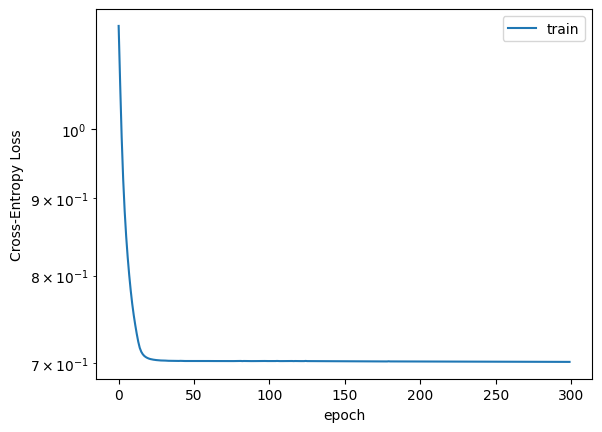

In [21]:
batch_size = 256
# Create dataloader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

nhidden = 4
# Define model, criterion and optimizer
model_tbr = nn.Sequential(	nn.Linear(1, nhidden),
        					nn.ReLU(),
        					nn.Linear(nhidden, 3))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_tbr.parameters(), lr=1e-3)

epochs = 300
train_losses = []  

# Training loop
model_tbr.train()

pbar = tqdm(range(epochs))
for epoch in pbar:
    model_tbr.train()
    running_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        outputs = model_tbr(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        # Accuracy
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)


    # End epoch statistics
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / total

    train_losses.append(train_loss)

    # Print loss in the progression bar
    pbar.set_postfix(train=train_loss,  lr=optimizer.param_groups[0]['lr'])

# Save the final model weights
#torch.save(model.state_dict(), weight_filename)
# Plot losses
plt.figure()
plt.plot(train_losses, label='train')
plt.yscale('log') 
plt.legend(); plt.xlabel('epoch'); plt.ylabel('Cross-Entropy Loss')
plt.show()	

To investigate whether the function learned by the neural network is genuinely nonlinear, we compare its performance with that of a linear classification model. In particular, we train a logistic regression classifier.


Training loss (Logistic Regression, log-loss): 0.7026301446723746
Training accuracy (Logistic Regression): 0.564651651301202
Training loss (NN, cross-entropy): 0.7015126347541809
Training accuracy (NN): 0.5646516680717468


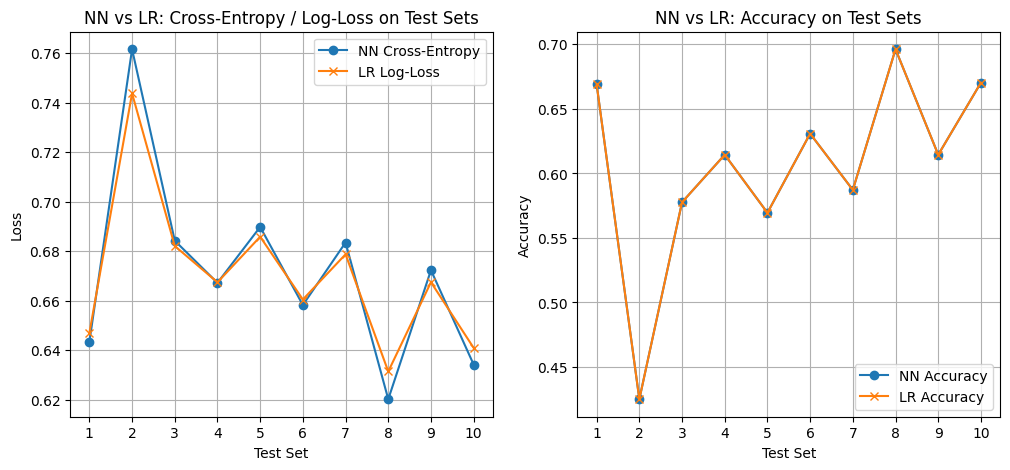

In [23]:
# Test evaluation: Logistic Regression (log-loss + accuracy) 
lr_test_losses = []
lr_test_accs   = []

for i in range(10):
    proba = clf.predict_proba(X_test_windows[i]) 
    preds = np.argmax(proba, axis=1)

    loss = log_loss(y_test_windows[i], proba, labels=[0, 1, 2])
    acc  = accuracy_score(y_test_windows[i], preds)

    lr_test_losses.append(loss)
    lr_test_accs.append(acc)

# Test evaluation: Neural Network (cross-entropy + accuracy) 
nn_test_losses = []
nn_test_accs   = []

model_tbr.eval()
with torch.no_grad():
    for i in range(10):
        outputs = model_tbr(X_test_tensors[i])  # logits
        loss = criterion(outputs, y_test_tensors[i]).item()
        preds = outputs.argmax(dim=1)
        acc = (preds == y_test_tensors[i]).float().mean().item()

        nn_test_losses.append(loss)
        nn_test_accs.append(acc)

# Training evaluation: Logistic Regression 
train_proba = clf.predict_proba(X_train_scaled)
train_preds = np.argmax(train_proba, axis=1)

lr_train_loss = log_loss(y_train, train_proba, labels=[0, 1, 2])
lr_train_acc  = accuracy_score(y_train, train_preds)

print("Training loss (Logistic Regression, log-loss):", lr_train_loss)
print("Training accuracy (Logistic Regression):", lr_train_acc)

# Training evaluation: Neural Network
model_tbr.eval()
with torch.no_grad():
    outputs = model_tbr(X_train_tensor)  # logits
    nn_train_loss = criterion(outputs, y_train_tensor).item()
    preds = outputs.argmax(dim=1)
    nn_train_acc = (preds == y_train_tensor).float().mean().item()

print("Training loss (NN, cross-entropy):", nn_train_loss)
print("Training accuracy (NN):", nn_train_acc)

# Compare NN and LR on the 10 test sets 
plt.figure(figsize=(12, 5))

# Loss (cross-entropy / log-loss)
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), nn_test_losses, marker='o', label='NN Cross-Entropy')
plt.plot(range(1, 11), lr_test_losses, marker='x', label='LR Log-Loss')
plt.title("NN vs LR: Cross-Entropy / Log-Loss on Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Loss")
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, 11), nn_test_accs, marker='o', label='NN Accuracy')
plt.plot(range(1, 11), lr_test_accs, marker='x', label='LR Accuracy')
plt.title("NN vs LR: Accuracy on Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Accuracy")
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True)

plt.show()


## Train-Test Distribution Shift

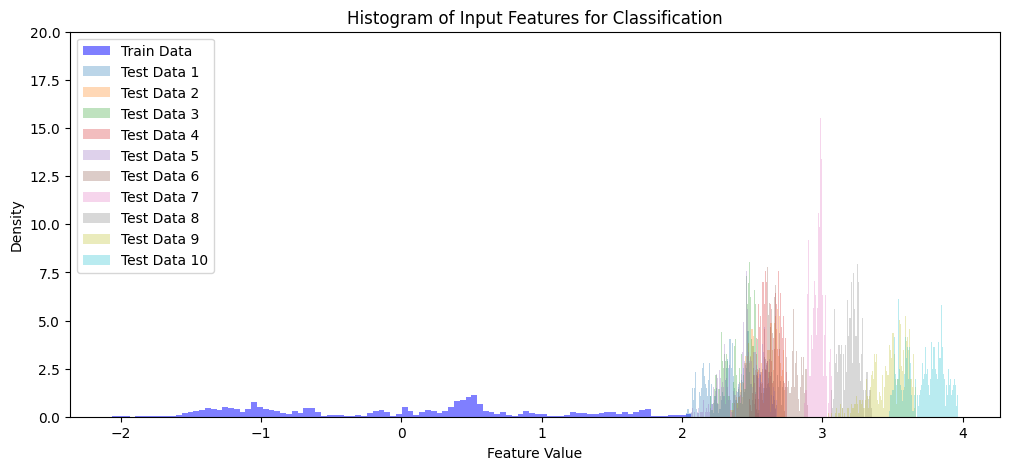

In [24]:
# Plotting histograms of input features
plt.figure(figsize=(12, 5))
plt.hist(X_train_scaled, bins=100, alpha=0.5, label='Train Data', color='blue', density=True)
for i in range(10):
	plt.hist(X_test_windows[i], bins=100, alpha=0.3, label=f'Test Data {i+1}', density=True)
plt.title("Histogram of Input Features for Classification")
plt.xlabel("Feature Value")
plt.ylabel("Density")
plt.legend()
plt.show()


## NN vs LR : Learned functions

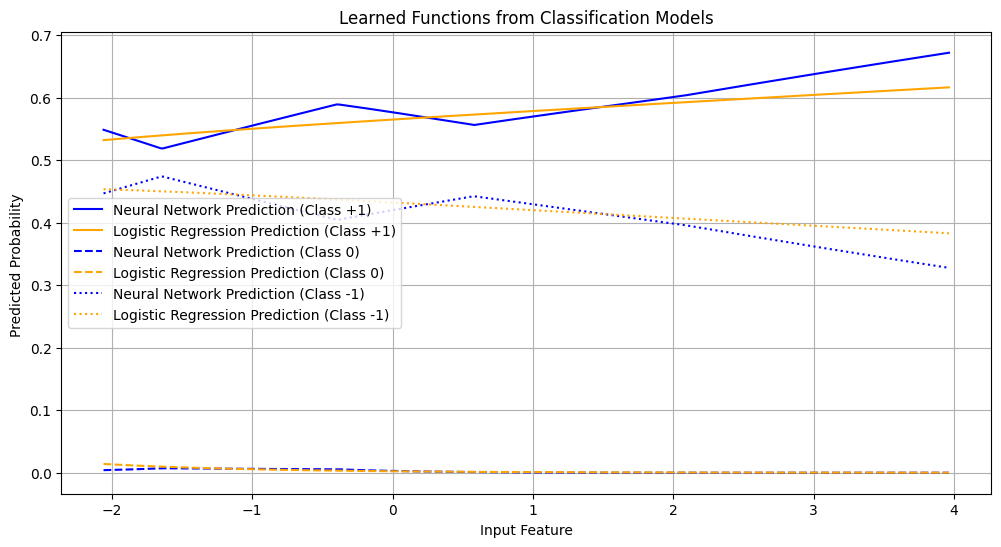

In [25]:
# Plotting the learned functions from both models
x_min = min(X_train_scaled.min(), 
            min([X_test_windows[i].min() for i in range(10)]))
x_max = max(X_train_scaled.max(), 
            max([X_test_windows[i].max() for i in range(10)]))

x_vals = np.linspace(x_min, x_max, 400).reshape(-1, 1)
model_tbr.eval()
with torch.no_grad():
	y_vals_nn = model_tbr(torch.as_tensor(x_vals, dtype=torch.float32)).numpy()
	# Convert logits to probabilities
	y_vals_nn = nn.Softmax(dim=1)(torch.as_tensor(y_vals_nn)).numpy()
y_vals_lr = clf.predict_proba(x_vals)
plt.figure(figsize=(12, 6))
# Class +1
plt.plot(x_vals, y_vals_nn[:, 2], label='Neural Network Prediction (Class +1)', color='blue')
plt.plot(x_vals, y_vals_lr[:, 2], label='Logistic Regression Prediction (Class +1)', color='orange')
# Class 0
plt.plot(x_vals, y_vals_nn[:, 1], label='Neural Network Prediction (Class 0)', color='blue', linestyle='--')
plt.plot(x_vals, y_vals_lr[:, 1], label='Logistic Regression Prediction (Class 0)', color='orange', linestyle='--')
# Class -1
plt.plot(x_vals, y_vals_nn[:, 0], label='Neural Network Prediction (Class -1)', color='blue', linestyle=':')
plt.plot(x_vals, y_vals_lr[:, 0], label='Logistic Regression Prediction (Class -1)', color='orange', linestyle=':')
plt.title("Learned Functions from Classification Models")
plt.xlabel("Input Feature")
plt.ylabel("Predicted Probability ")
plt.legend()
plt.grid()
plt.show()
